# Validating RFR with artificial gaps

Real gaps have no truth to score against, so the paper validates by hiding
stretches of genuinely measured data, fitting on what is left and scoring the
predictions for the hidden stretches. This notebook runs that experiment on
a synthetic site and looks at the three places where it is easy to get wrong:

1. **the gap scenario**: 24-hour, 7-day and 30-day gaps withholding about 25%
   of the measurements, and what "20/30/50" counts (ambiguity A3);
2. **long gaps**: which rows can be predicted at all when a gap covers whole
   days (ambiguity A4);
3. **leakage**: keeping the hidden truth out of the features that predict it,
   and how much a leaky derivation flatters the score.

The guide to all of this is [`docs/validation.md`](../../docs/validation.md).
The notebook runs in about a minute.

In [1]:
import tempfile
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from rfrgapfill import (
    FeatureConfig,
    GapScenarioGenerator,
    LegacyFluxlibWarning,
    build_validation_features,
    detect_target_leakage,
    gap_class_labels,
    gap_length_pivot,
    gap_length_table,
    synthetic_site,
    validate_rfr,
)

# Show warnings as one line, without the path of the file that raised them.
warnings.formatwarning = lambda message, category, *args, **kwargs: (
    f"{category.__name__}: {message}\n"
)

# Series colours, always used in this order, and grey for the chart furniture.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
MUTED = "#898781"
plt.rcParams.update(
    {
        "figure.figsize": (10, 3.6),
        "axes.prop_cycle": plt.cycler(color=SERIES),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "#c3c2b7",
        "axes.labelcolor": "#52514e",
        "axes.titlelocation": "left",
        "axes.grid": True,
        "grid.color": "#e1e0d9",
        "grid.linewidth": 0.6,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "lines.linewidth": 1.5,
        "legend.frameon": False,
    }
)

CLASS_ORDER = ["short", "long", "very_long"]
CLASS_LABEL = {"short": "24 h", "long": "7 d", "very_long": "30 d"}


def label(value):
    """Return a gap class as its plain string, whether it arrived as an enum or not."""
    return getattr(value, "value", value)

In [2]:
site = synthetic_site()
targets = list(site.targets)
qc = dict(site.qc_columns())
config = site.config(
    "RFR3",
    features=FeatureConfig(daily_statistic_strategy="rolling_available"),
    hyperparameter_grid={"n_estimators": (50,)},
    n_jobs=-1,
)

## 1. The gap scenario

`GapScenarioGenerator` places the paper's design: about 25% of the measured
values withheld, as 24-hour, 7-day and 30-day gaps mixed 20/30/50, each gap
sitting over at least 50% real measurements. Passing all three targets places
**one** set of gaps that every flux is scored on, the paper's joint NEE/H/LE
rule.

What was achieved is measured from the placed gaps and reported next to what
was asked for, never adjusted to look exact. Real outages under the gaps
usually leave the achieved fraction below 25% (ambiguity A7).

In [3]:
gaps = GapScenarioGenerator(config).generate(site.frame, target=targets, qc_column=qc)
print(gaps.summary())

withheld 2282 of 12518 available observation(s) (18.2%, requested 25.0%) as 17 gap(s) under allocation_basis='missing_records': short 13 x P1DT0H0M0S (22% of records, requested 20%); long 3 x P7DT0H0M0S (33% of records, requested 30%); very_long 1 x P30DT0H0M0S (45% of records, requested 50%)


In [4]:
gaps.to_frame()

,gap_id,gap_class,start,end,duration,n_expected,n_rows,n_observed_before_masking,observed_fraction
0,long-01,long,2018-01-16 12:30:00,2018-01-23 12:30:00,7 days,336,336,217,0.645833
1,short-01,short,2018-01-28 20:30:00,2018-01-29 20:30:00,1 days,48,48,41,0.854167
2,short-02,short,2018-02-11 03:00:00,2018-02-12 03:00:00,1 days,48,48,45,0.937500
3,short-03,short,2018-02-26 18:30:00,2018-02-27 18:30:00,1 days,48,48,26,0.541667
4,short-04,short,2018-03-05 23:30:00,2018-03-06 23:30:00,1 days,48,48,29,0.604167
5,long-02,long,2018-03-18 17:30:00,2018-03-25 17:30:00,7 days,336,336,281,0.836310
6,long-03,long,2018-04-19 02:30:00,2018-04-26 02:30:00,7 days,336,336,260,0.773810
7,short-05,short,2018-05-21 14:30:00,2018-05-22 14:30:00,1 days,48,48,42,0.875000
8,short-06,short,2018-07-17 01:00:00,2018-07-18 01:00:00,1 days,48,48,36,0.750000
9,short-07,short,2018-07-23 11:00:00,2018-07-24 11:00:00,1 days,48,48,36,0.750000


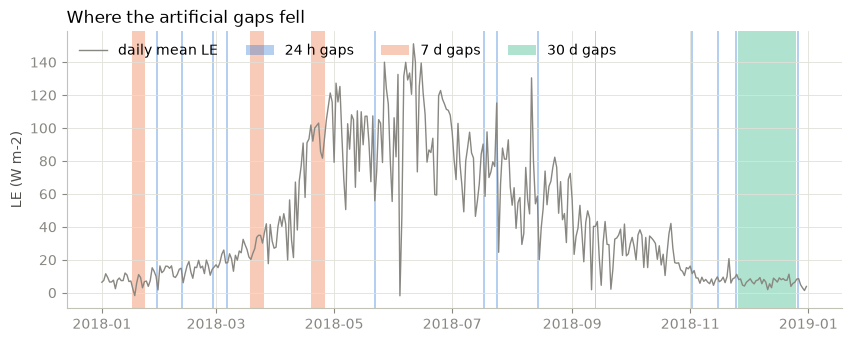

In [5]:
daily_le = site.frame["LE"].resample("D").mean()
fig, ax = plt.subplots()
ax.plot(daily_le.index, daily_le, color=MUTED, lw=1, label="daily mean LE")
for colour, gap_class in zip(SERIES[: len(CLASS_ORDER)], CLASS_ORDER, strict=True):
    for number, gap in enumerate(gaps.by_class(gap_class)):
        start, end = gap.interval()
        ax.axvspan(
            start,
            end,
            color=colour,
            alpha=0.35,
            lw=0,
            label=f"{CLASS_LABEL[gap_class]} gaps" if number == 0 else None,
        )
ax.set_title("Where the artificial gaps fell")
ax.set_ylabel("LE (W m-2)")
ax.legend(loc="upper left", ncols=4)
plt.show()

### What does 20/30/50 count? (A3)

The paper does not say whether the mix counts gap *events* or withheld
*records*, and the two readings give very different designs. The default is
`missing_records`; every manifest reports the achieved mix on both bases.
Here is the same request under each reading.

In [6]:
by_events = config.replace(
    validation=config.validation.replace(
        gaps=config.validation.gaps.replace(allocation_basis="gap_events")
    )
)
events_gaps = GapScenarioGenerator(by_events).generate(
    site.frame, target=targets, qc_column=qc, on_shortfall="warn"
)


def mix(manifest):
    return pd.DataFrame(
        {
            "gaps": {label(c): n for c, n in manifest.events_by_class.items()},
            "share of gaps": {label(c): s for c, s in manifest.event_shares.items()},
            "share of withheld records": {label(c): s for c, s in manifest.record_shares.items()},
        }
    ).reindex(CLASS_ORDER)


pd.concat({"missing_records (default)": mix(gaps), "gap_events": mix(events_gaps)}).round(2)

gaps  share of gaps  \
missing_records (default) short        13           0.76   
                          long          3           0.18   
                          very_long     1           0.06   
gap_events                short         1           0.25   
                          long          1           0.25   
                          very_long     2           0.50   

                                     share of withheld records  
missing_records (default) short                           0.22  
                          long                            0.33  
                          very_long                       0.45  
gap_events                short                           0.02  
                          long                            0.12  
                          very_long                       0.87

Counted by records, half the withheld data sits in 30-day gaps. Counted by
events, a 20/30/50 mix of gaps puts most of the withheld records in the
30-day class, because one 30-day gap withholds as many records as thirty
24-hour gaps.

## 2. Long gaps need a daily-statistic strategy (A4)

The receptive limiter includes daily quartiles and the daily standard
deviation of the flux being predicted, computed only from values the model is
allowed to see. A gap covering a whole calendar day leaves that day with no
visible values. Under the default `daily_statistic_strategy="missing"` its
statistics are missing, so none of its rows can be predicted.

`build_validation_features` is the leakage-safe feature workflow that
`validate_rfr` uses internally. It lets you check, before fitting anything,
how many withheld rows each strategy can predict.

In [7]:
holdout = gaps.mask(site.frame.index)
classes = gap_class_labels(gaps, site.frame.index).map(label)

strategies = {
    "missing (default)": FeatureConfig(daily_statistic_strategy="missing"),
    "within_day_available": FeatureConfig(daily_statistic_strategy="within_day_available"),
    "neighbor_day_fallback": FeatureConfig(daily_statistic_strategy="neighbor_day_fallback"),
    "rolling_available": FeatureConfig(daily_statistic_strategy="rolling_available"),
    "rolling_available, 15-day window": FeatureConfig(
        daily_statistic_strategy="rolling_available", fallback_window_days=15
    ),
}
coverage = {}
for name, features_config in strategies.items():
    features = build_validation_features(
        site.frame,
        config=config.replace(features=features_config),
        target="LE",
        holdout=holdout,
        qc_column="LE_QC",
    )
    complete = features.complete_mask[holdout]
    coverage[name] = complete.groupby(classes[holdout]).mean().reindex(CLASS_ORDER)

(pd.DataFrame(coverage).T.rename(columns=CLASS_LABEL) * 100).round(1).rename_axis(
    "% of withheld rows predictable"
)

gap_class,24 h,7 d,30 d
% of withheld rows predictable,,,
missing (default),77.4,14.3,3.3
within_day_available,77.4,14.3,3.3
neighbor_day_fallback,77.4,100.0,50.0
rolling_available,77.4,100.0,50.0
"rolling_available, 15-day window",77.4,100.0,100.0


With the default, a row can be predicted only if some of its own day is
still visible. That covers most of a 24-hour gap, which straddles two partly
visible days, but only the ragged ends of the 7-day gaps and almost none of the
30-day gap. `within_day_available` cannot help, because a day with no visible
value has nothing to use.

The strategies that reach across days, `neighbor_day_fallback` and
`rolling_available`, cover the 7-day gaps completely. With their default
`fallback_window_days=7` they cover only half of the 30-day gap: its middle
is more than seven days from any visible value. A 15-day window reaches all of
it.

The withheld rows still missing in the 24-hour gaps lack only the daily
standard deviation. A day the gap leaves with a single visible value has no
sample standard deviation (`daily_std_ddof=1`, ambiguity A11).

Every strategy uses only visible measurements, so none of them leaks; the
choice is recorded in every run manifest. The rest of this notebook keeps the
7-day window, so its 30-day scores cover the half of the gap nearer to visible
data, and `n` against `n_offered` in the results shows exactly that.

## 3. Leakage

If the daily statistics were computed *before* the gaps were hidden, a hidden
value would help build the features used to predict it. The default
`feature_mode="paper_safe"` prevents that in two independent ways, and
`detect_target_leakage` checks it: it replaces the hidden truth with absurd
values, rebuilds every feature, and returns any column that moved.

In [8]:
print("paper_safe:", detect_target_leakage(site.frame, config=config, target="LE", holdout=holdout))

paper_safe: ()


The paper's archived `fluxlib` code computed its daily statistics before
hiding the gaps ([`docs/fluxlib_audit.md`](../../docs/fluxlib_audit.md),
finding F1). `feature_mode="legacy_fluxlib"` reproduces that derivation so the
effect can be measured. It brings its own daily-statistic rules, so it starts
from a fresh `FeatureConfig`, and it warns every time it is used.

In [9]:
legacy = config.replace(features=FeatureConfig(feature_mode="legacy_fluxlib"))
with warnings.catch_warnings():
    # The probe rebuilds the features several times; one copy of the warning is enough.
    warnings.simplefilter("once", LegacyFluxlibWarning)
    leaked = detect_target_leakage(site.frame, config=legacy, target="LE", holdout=holdout)
print("legacy_fluxlib:", leaked)

legacy_fluxlib: ('LE_legacy_max', 'LE_legacy_min', 'LE_legacy_mean', 'LE_legacy_std', 'LE_legacy_p25', 'LE_legacy_p50', 'LE_legacy_p75')


## 4. The experiment in one call

`validate_rfr` runs the stages in a fixed order: place the gaps (or take
them, as here), hide the truth, build leakage-safe features, fit on what is
left, predict the withheld rows and score them. `check_leakage=True` runs the
probe above as part of the run, and fails it if anything moved.

In [10]:
report = validate_rfr(
    site.frame, config=config, targets=targets, qc_columns=qc, gaps=gaps, check_leakage=True
)
table = report.to_frame()
table.head()

,target,method,mode,gap_class,subset,n,n_offered,r2,slope,rmse,bias
0,NEE,RFR3,RFR3,all,all,1997,2739,0.788226,0.810094,1.818973,0.177002
1,NEE,RFR3,RFR3,all,daytime,912,1211,0.718252,0.788531,2.543133,0.402374
2,NEE,RFR3,RFR3,all,nighttime,1085,1528,0.623277,0.653256,0.808374,-0.012435
3,NEE,RFR3,RFR3,short,all,437,567,0.748364,0.749721,2.054410,0.277379
4,NEE,RFR3,RFR3,short,daytime,230,287,0.428216,0.655192,2.660327,0.843216


The tidy table has one row per target, gap class and day/night subset. Pivoted
for reading, R2 and RMSE by gap length, over all withheld rows:

In [11]:
everything = table[table["subset"] == "all"]


def by_gap_class(rows, metric, index="target"):
    """One metric as rows by gap class, the classes in duration order."""
    wide = rows.pivot_table(index=index, columns="gap_class", values=metric)
    return wide.reindex(columns=["all", *CLASS_ORDER])


pd.concat(
    {"R2": by_gap_class(everything, "r2"), "RMSE": by_gap_class(everything, "rmse")},
    axis=1,
).reindex(targets).round(3)

R2                            RMSE                          
gap_class    all  short   long very_long     all   short    long very_long
target                                                                    
NEE        0.788  0.748  0.795    -0.093   1.819   2.054   2.198     0.723
H          0.934  0.920  0.937     0.935  20.895  26.712  21.149    15.367
LE         0.912  0.905  0.914     0.617  19.188  18.887  23.144    10.132

Read the metrics together. RMSE and bias are in each flux's own units
(µmol m-2 s-1 for NEE, W m-2 for H and LE), and R2 needs variance to
explain: a gap falling in a quiet season can have a small RMSE and a poor R2.
Nighttime skill is weak for heat fluxes everywhere, and the `all` rows hide
it, so always look at the day/night split too:

In [12]:
by_gap_class(table[table["target"] == "LE"], "r2", index="subset").round(3)

gap_class,all,short,long,very_long
subset,,,,
all,0.912,0.905,0.914,0.617
daytime,0.888,0.860,0.879,0.559
nighttime,-0.136,-0.188,-0.129,-0.134


`n` against `n_offered` says how many withheld rows were scored out of how
many were withheld. Beyond the core metrics, the report carries the spread of
bias across the individual gaps of each class and the energy-balance ratio
computed from the measured and the filled H and LE, over the same rows:

In [13]:
report.bias_spread_frame().round(3)

,target,method,mode,gap_class,n_gaps,n_gaps_offered,bias_q1,bias_median,bias_q3,bias_iqr
0,NEE,RFR3,RFR3,short,12,13,-0.255,0.030,0.227,0.482
1,NEE,RFR3,RFR3,long,3,3,-0.114,0.016,0.481,0.595
2,NEE,RFR3,RFR3,very_long,1,1,0.019,0.019,0.019,NaN
3,H,RFR3,RFR3,short,11,13,-14.826,-0.925,2.985,17.812
4,H,RFR3,RFR3,long,3,3,-4.074,-0.152,0.801,4.875
5,H,RFR3,RFR3,very_long,1,1,-0.602,-0.602,-0.602,NaN
6,LE,RFR3,RFR3,short,12,13,-6.981,-3.172,1.557,8.538
7,LE,RFR3,RFR3,long,3,3,-7.047,-1.815,-0.379,6.668
8,LE,RFR3,RFR3,very_long,1,1,0.900,0.900,0.900,NaN


In [14]:
report.energy_balance_frame().round(4)

,method,mode,sensible_heat,latent_heat,gap_class,n,n_offered,n_missing_measured,n_missing_filled,n_missing_available_energy,available_energy,measured_ebr,filled_ebr,difference
0,RFR3,RFR3,H,LE,all,1786,3072,543,861,0,120181.8722,0.8492,0.7635,-0.0857
1,RFR3,RFR3,H,LE,short,429,624,91,141,0,38461.3306,0.8582,0.7528,-0.1054
2,RFR3,RFR3,H,LE,long,828,1008,180,0,0,75114.9195,0.8485,0.7610,-0.0875
3,RFR3,RFR3,H,LE,very_long,529,1440,272,720,0,6605.6221,0.8051,0.8537,0.0485


The 30-day gap, withheld truth against RFR3's prediction. The prediction
covers the first and last weeks and stops in between. Those middle rows are
more than seven days from any visible value, so they have no daily statistics
and are left unpredicted rather than guessed (section 2).

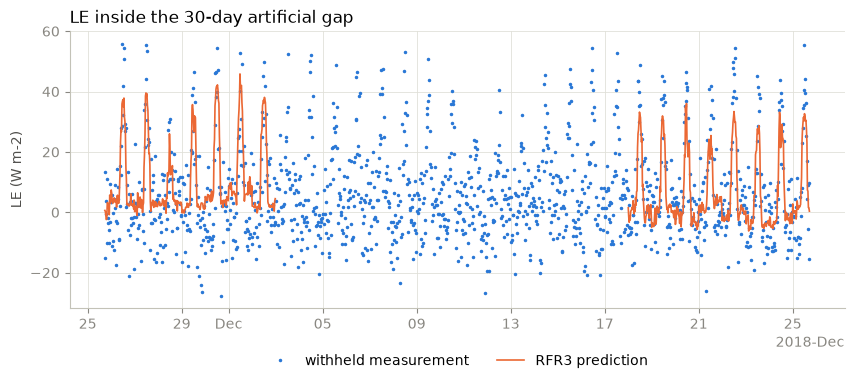

In [15]:
result = report["LE"]
start, end = gaps.by_class("very_long")[0].interval()
inside = slice(start, end - pd.Timedelta("1ns"))
fig, ax = plt.subplots()
ax.plot(result.features.truth[inside], ".", ms=3, label="withheld measurement")
ax.plot(result.predictions[inside], lw=1.2, label="RFR3 prediction")
ax.set_title("LE inside the 30-day artificial gap")
ax.set_ylabel("LE (W m-2)")
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncols=2)
plt.show()

## 5. How much does leakage flatter a score?

Run the same experiment on the same gaps with the historical, leaky feature
derivation and put the two side by side. The legacy arm is labelled
`RFR3-legacy` and is never paper faithful.

In [16]:
legacy_report = validate_rfr(site.frame, config=legacy, targets=targets, qc_columns=qc, gaps=gaps)
both = gap_length_table([report, legacy_report], site=site.site_id)
pd.concat(
    {
        label(gap_class): gap_length_pivot(both, metric="rmse", gap_class=gap_class)
        for gap_class in CLASS_ORDER
    },
    axis=1,
).round(3)

short                long             very_long            
          RFR3 RFR3-legacy    RFR3 RFR3-legacy      RFR3 RFR3-legacy
target                                                              
H       26.712      18.046  21.149      15.842    15.367      15.139
LE      18.887      13.419  23.144      14.809    10.132      10.038
NEE      2.054       1.027   2.198       1.022     0.723       0.738

For the 24-hour and 7-day gaps the legacy arm's RMSE is roughly a third to a
half lower. That is not a better method: those predictions were built partly
from the values they are scored against, help no real gap will ever give. The
30-day gap barely changes, because a whole month of hidden values says little
about any one day's statistics. That is why `paper_safe` is the default.

## 6. Record the run

Each target's manifest records the configuration, the placed gaps, the row
accounting, the fitted parameters and every ambiguity choice.

In [17]:
with tempfile.TemporaryDirectory() as directory:
    for target in targets:
        path = report.manifest(target).save(Path(directory) / f"{report.method}_{target}.json")
        print("wrote", path.name)

wrote RFR3_NEE.json
wrote RFR3_H.json
wrote RFR3_LE.json
